In [1]:
from configs import *


In [12]:
def simulate(bird, world, n_episodes, time_steps, train=False):
    """ Simulate bird, possible episodic SARSA. """

    # Initialize trajectory tracking [episode, time_step, SAR]
    hist = np.zeros((n_episodes, time_steps, 3), dtype=int)

    # Episodic loop
    for epi in range(n_episodes):

        # Random initial state, first bird action
        x, y, z = world.random_state_coords()
        state  = world.state_to_index(x, y, z)
        action = bird.policy(state)
        bird.register_action() 

        # Time-step loop
        for t in range(0, time_steps):
            # Transition state, get bird action and reward
            next_state  = world.transition(state, action)
            reward      = world.reward(next_state)
            next_action = bird.policy(next_state)
            bird.register_action()

            # Learning
            if train: bird.update(state, action, reward, next_state, next_action)

            # Save trajectory information
            hist[epi, t, :] = (state, action, reward)

            # Cycle current state and action
            state, action  = next_state, next_action

    return hist

## RL bird

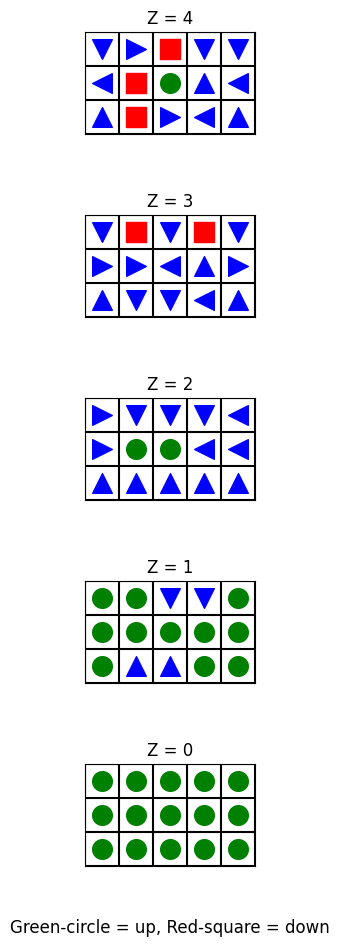

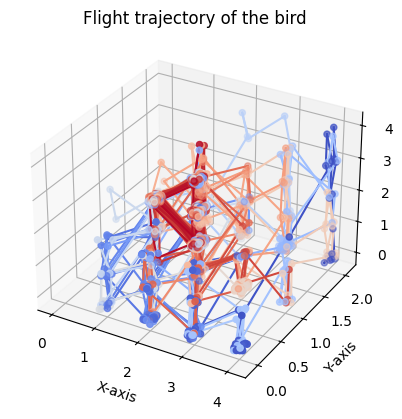

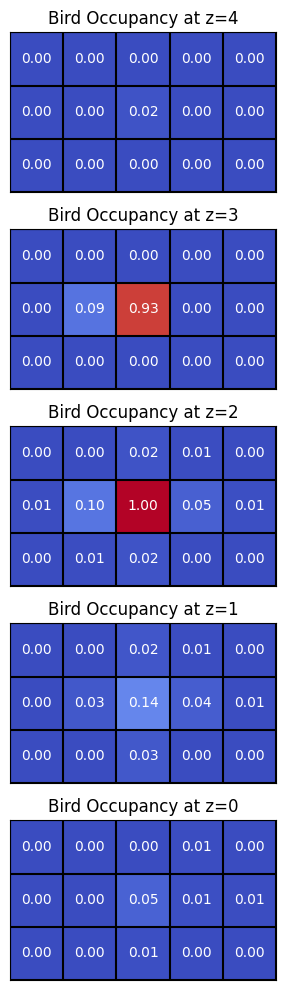

In [21]:
# Create environment
world = World(x_size = 5, y_size = 3, z_size = 5, wind = [0.0, 0.0, 0.0])

# Create the bird and a world model for the bird
rl_bird = RLShittyBird(
    n_states=world.n_states,
    n_actions=world.n_actions,
    n_planning=1,
    update_type='SARSA'
)
bad_model = World(x_size=5, y_size=3, z_size=5, wind=[0.0, 0.0, 0.0])
rl_bird.init_transition_model(bad_model)

# Save the initial q_values
q_values_prior = rl_bird.action_values.flatten()

# Train the bird
rl_bird_hist = simulate(
    rl_bird,
    world,
    n_episodes=1000,
    time_steps=1000,
    train=True
)

# Save the final q_values
q_values_post = rl_bird.action_values.flatten()

# Plot action values
plot_action_values(rl_bird, world)

# Plot bird's flight path on the final episode
plot_flight_trajectory(rl_bird_hist, world)

# Plot its final episode state occupancy
plot_state_occupancy_heatmap(rl_bird_hist, world)


## Dan's MPC bird

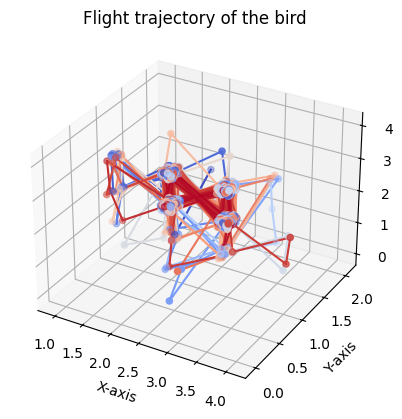

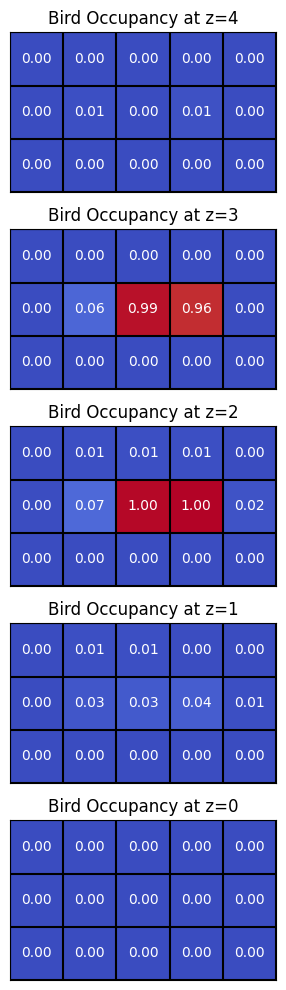

In [22]:
# Create environment
world = World(x_size = 5, y_size = 3, z_size = 5, wind = [0.0, 0.0, 0.0])

# Create bird
mpc_bird = MPCShittyBird(n_actions = world.n_actions, recompute = 1)
mpc_bird.init_transition_model(world)

# Get performance
mpc_bird_hist = simulate(mpc_bird, world, n_episodes=5, time_steps=1000, train=True)

# Plot bird's flight path on the final episode
plot_flight_trajectory(mpc_bird_hist, world)

# Plot it's final episode state occupancy
plot_state_occupancy_heatmap(mpc_bird_hist, world)